<a href="https://colab.research.google.com/github/rubyat43/220143_SVM_-_KNN/blob/main/220143_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


# ***Mount Google Drive.***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ***Library Functions.***

In [3]:
df = pd.read_csv('/content/drive/MyDrive/220143_AI_ML/Task_3_SVM_&_KNN/diabetes.csv')
print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)
df.head()

Dataset loaded successfully!
Rows and Columns: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# ***Dataset directly loaded from Google Drive.***

In [8]:
print("📐 Dataset Shape:", df.shape)
print(f"\n We have {df.shape[0]} patients and {df.shape[1]} features\n")

print(" Column Names:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

print(" Dataset Info:")
print("\n")
df.info()

print(" Statistical Summary:")
df.describe().round(2)

📐 Dataset Shape: (768, 9)

 We have 768 patients and 9 features

 Column Names:
  1. Pregnancies
  2. Glucose
  3. BloodPressure
  4. SkinThickness
  5. Insulin
  6. BMI
  7. DiabetesPedigreeFunction
  8. Age
  9. Outcome
 Dataset Info:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


# ***Data Exploration e.g. Basic shape & column info, data types & memory info and statistical summary.***

Target Column - Outcome (0 = No Diabetes, 1 = Diabetes):
Outcome
0    500
1    268
Name: count, dtype: int64

  No Diabetes (0): 500 people (65.1%)
  Has Diabetes (1): 268 people (34.9%)


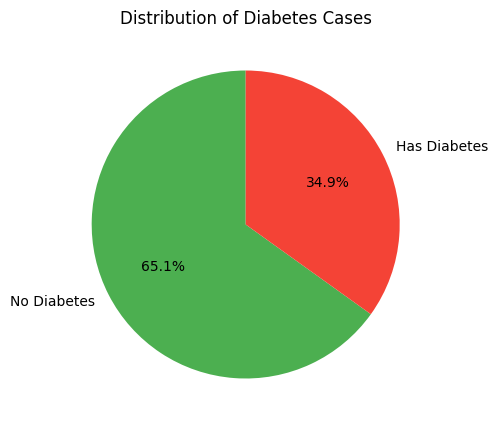

In [10]:
print("Target Column - Outcome (0 = No Diabetes, 1 = Diabetes):")
print(df['Outcome'].value_counts())
print()
print(f"  No Diabetes (0): {df['Outcome'].value_counts()[0]} people ({df['Outcome'].value_counts()[0]/len(df)*100:.1f}%)")
print(f"  Has Diabetes (1): {df['Outcome'].value_counts()[1]} people ({df['Outcome'].value_counts()[1]/len(df)*100:.1f}%)")

plt.figure(figsize=(5,5))
plt.pie(df['Outcome'].value_counts(),
        labels=['No Diabetes', 'Has Diabetes'],
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'],
        startangle=90)
plt.title('Distribution of Diabetes Cases')
plt.show()

# ***Check the target column (What we're predicting). Data Exploration.***

In [11]:
impossible_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Hidden Missing Values (disguised as zeros):")
print("\n")
for col in impossible_zero_cols:
    zero_count = (df[col] == 0).sum()
    percentage = zero_count / len(df) * 100
    print(f"  {col:20s}: {zero_count} zeros ({percentage:.1f}%)")

Hidden Missing Values (disguised as zeros):


  Glucose             : 5 zeros (0.7%)
  BloodPressure       : 35 zeros (4.6%)
  SkinThickness       : 227 zeros (29.6%)
  Insulin             : 374 zeros (48.7%)
  BMI                 : 11 zeros (1.4%)


# ***Find the hidden missing values (Zeros). Data Exploration.***

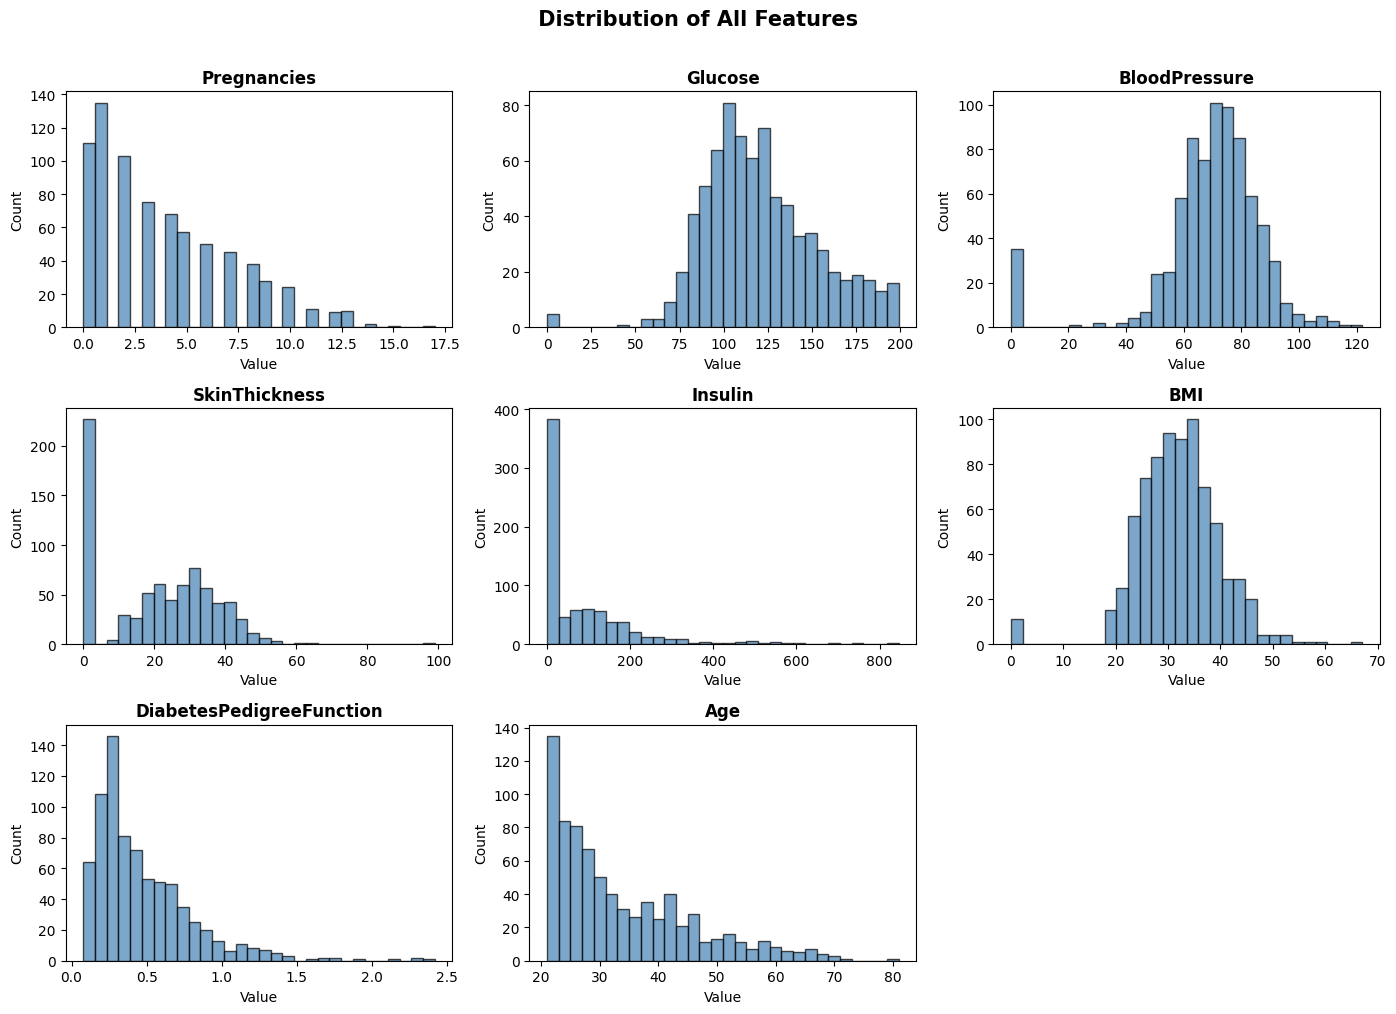

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

features = df.columns[:-1]

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)

plt.suptitle(' Distribution of All Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ***Distribution of every feature. (Data Exploration.)***

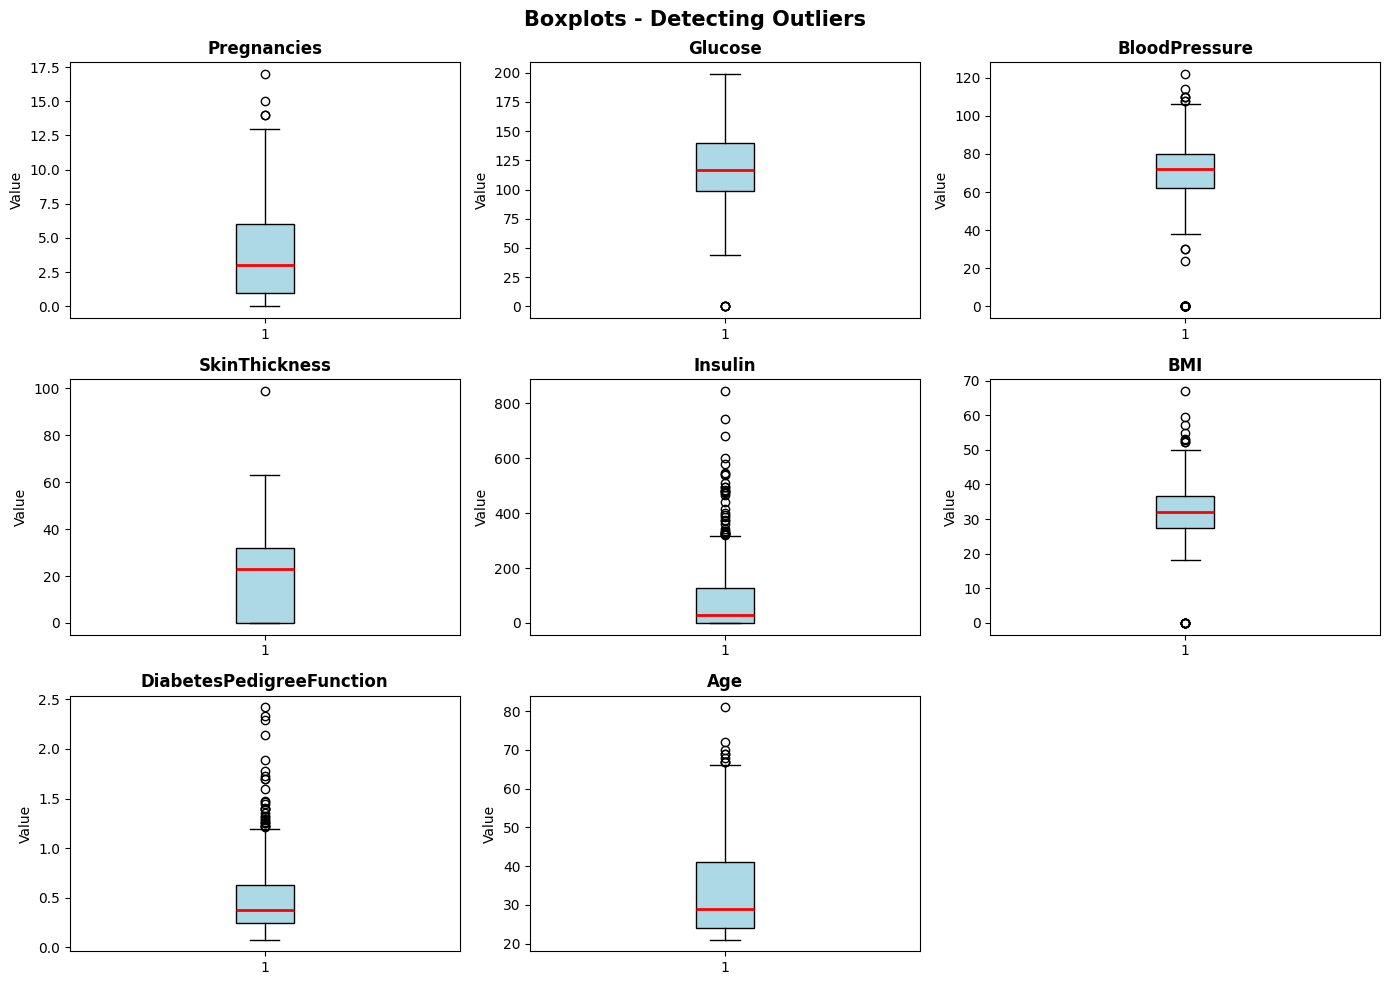

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')

axes[-1].set_visible(False)
plt.suptitle('Boxplots - Detecting Outliers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ***Boxplots — Spot outliers. (Data Exploration).***

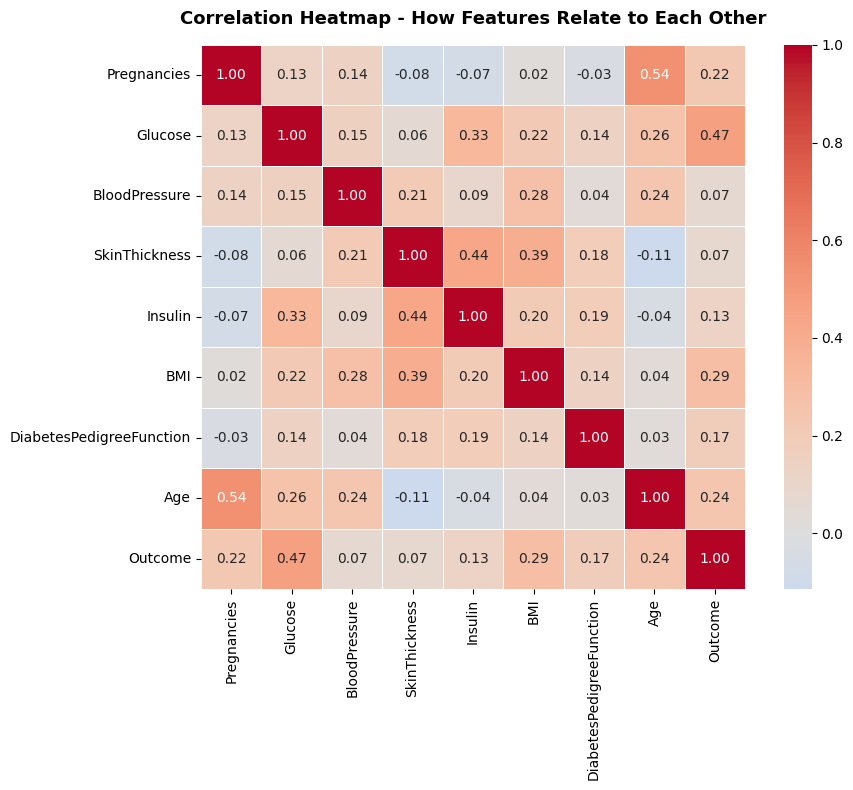

In [15]:
plt.figure(figsize=(10, 8))
correlation = df.corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap - How Features Relate to Each Other',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ***Correlation Heatmap. (Data Exploration)***

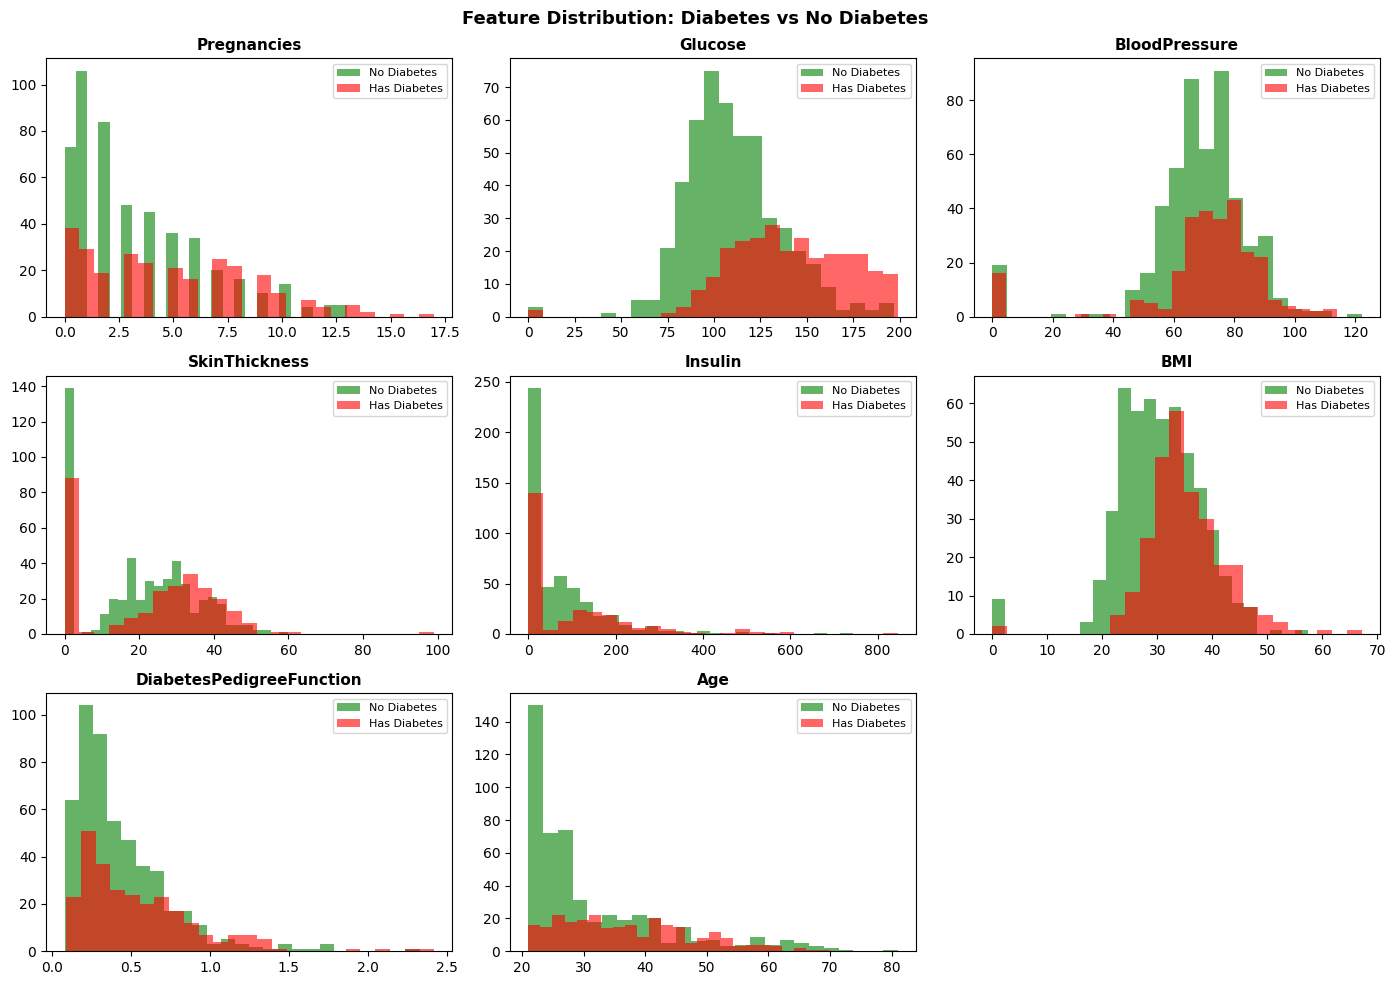

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):

    no_diabetes = df[df['Outcome'] == 0][col]
    has_diabetes = df[df['Outcome'] == 1][col]

    axes[i].hist(no_diabetes, bins=25, alpha=0.6, color='green', label='No Diabetes')
    axes[i].hist(has_diabetes, bins=25, alpha=0.6, color='red', label='Has Diabetes')
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Feature Distribution: Diabetes vs No Diabetes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ***Feature vs Outcome (Grouped Comparison). (Data Exploration).***

In [17]:
impossible_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in impossible_zero_cols:
    median_value = df[col].median()
    df[col] = df[col].replace(0, median_value)
    print(f" {col:20s}: zeros replaced with median value of {median_value}")

print("\n All hidden missing values fixed!")

 Glucose             : zeros replaced with median value of 117.0
 BloodPressure       : zeros replaced with median value of 72.0
 SkinThickness       : zeros replaced with median value of 23.0
 Insulin             : zeros replaced with median value of 30.5
 BMI                 : zeros replaced with median value of 32.0

 All hidden missing values fixed!


# ***Fix the hidden missing values.***

In [18]:
impossible_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Checking zeros after fix:")
print("\n")
for col in impossible_zero_cols:
    zero_count = (df[col] == 0).sum()
    print(f" {col:20s}: {zero_count} zeros remaining")

print("\nAll columns should show 0 zeros now!")

Checking zeros after fix:


 Glucose             : 0 zeros remaining
 BloodPressure       : 0 zeros remaining
 SkinThickness       : 0 zeros remaining
 Insulin             : 0 zeros remaining
 BMI                 : 0 zeros remaining

All columns should show 0 zeros now!


# ***Verify the fix.***

In [36]:
print("Checking for Categorical Columns:")
print("\n")

categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(f"\n  Categorical columns found : {len(categorical_cols)}")
print(f"  Numerical columns found   : {len(numerical_cols)}")

if len(categorical_cols) == 0:
    print("\n No categorical columns found in this dataset!")
    print("   All features are already numerical.")
else:
    print(f"\n  Categorical columns: {list(categorical_cols)}")

Checking for Categorical Columns:



  Categorical columns found : 0
  Numerical columns found   : 9

 No categorical columns found in this dataset!
   All features are already numerical.


# ***Check and encode categorical features.***

In [37]:
from sklearn.preprocessing import LabelEncoder

demo_df = pd.DataFrame({
    'Gender'        : ['Male', 'Female', 'Female', 'Male', 'Male'],
    'SmokingStatus' : ['Never', 'Current', 'Former', 'Never', 'Current'],
    'AgeGroup'      : ['Young', 'Middle', 'Old', 'Young', 'Old'],
    'HasDiabetes'   : [1, 0, 1, 0, 1]
})

print(" Original Data with Categorical Columns:")
print(demo_df)
print()

le = LabelEncoder()
demo_df['Gender_Encoded'] = le.fit_transform(demo_df['Gender'])
print(" Label Encoding applied on Gender:")
print("   Male → 1, Female → 0")
print()

demo_df = pd.get_dummies(demo_df, columns=['SmokingStatus', 'AgeGroup'])
print(" One Hot Encoding applied on SmokingStatus and AgeGroup:")
print()

print(" Final Data after Encoding:")
print(demo_df)

 Original Data with Categorical Columns:
   Gender SmokingStatus AgeGroup  HasDiabetes
0    Male         Never    Young            1
1  Female       Current   Middle            0
2  Female        Former      Old            1
3    Male         Never    Young            0
4    Male       Current      Old            1

 Label Encoding applied on Gender:
   Male → 1, Female → 0

 One Hot Encoding applied on SmokingStatus and AgeGroup:

 Final Data after Encoding:
   Gender  HasDiabetes  Gender_Encoded  SmokingStatus_Current  \
0    Male            1               1                  False   
1  Female            0               0                   True   
2  Female            1               0                  False   
3    Male            0               1                  False   
4    Male            1               1                   True   

   SmokingStatus_Former  SmokingStatus_Never  AgeGroup_Middle  AgeGroup_Old  \
0                 False                 True            False     

# ***Demonstrate categorical encoding.***

In [19]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized successfully!")
print(f"\nBefore scaling - Glucose mean: {df['Glucose'].mean():.2f}")
print(f"After scaling  - Glucose mean: {X_scaled[:, 1].mean():.2f}")
print(f"\nBefore scaling - Glucose std: {df['Glucose'].std():.2f}")
print(f"After scaling  - Glucose std: {X_scaled[:, 1].std():.2f}")

Features standardized successfully!

Before scaling - Glucose mean: 121.66
After scaling  - Glucose mean: 0.00

Before scaling - Glucose std: 30.44
After scaling  - Glucose std: 1.00


# ***Standardize the features.***

In [20]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42)

print("Data split successfully!")
print("\n")
print(f"  Total dataset    : {len(X_scaled)} samples")
print(f"  Training set     : {len(X_train)} samples")
print(f"  Validation set   : {len(X_val)} samples")
print(f"  Test set         : {len(X_test)} samples")

Data split successfully!


  Total dataset    : 768 samples
  Training set     : 491 samples
  Validation set   : 123 samples
  Test set         : 154 samples


# ***Split the data into train, validation and test sets.***

In [21]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

print("SVM Model trained successfully!")
print("\n")
print(f"  Kernel used      : RBF")
print(f"  Trained on       : {len(X_train)} samples")

SVM Model trained successfully!


  Kernel used      : RBF
  Trained on       : 491 samples


# ***Train the first SVM model.***

In [22]:
from sklearn.metrics import accuracy_score

y_val_pred = svm_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

print("Model Performance on Validation Set:")
print("\n")
print(f"  Accuracy: {val_accuracy*100:.2f}%")

Model Performance on Validation Set:


  Accuracy: 72.36%


# ***Check model accuracy on validation set.***

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'degree': [2, 3, 4]
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("Searching for best parameters... this may take a minute!")
grid_search.fit(X_train, y_train)

print("\nSearch complete!")
print("\n")
print(f"  Best Parameters  : {grid_search.best_params_}")
print(f"  Best Accuracy    : {grid_search.best_score_*100:.2f}%")

Searching for best parameters... this may take a minute!
Fitting 5 folds for each of 144 candidates, totalling 720 fits

Search complete!


  Best Parameters  : {'C': 1, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}
  Best Accuracy    : 76.17%


# ***Hyperparameter tuning with GridSearchCV.***

In [25]:
best_params = grid_search.best_params_

print("Best Parameters Found:")
print("\n")
for param, value in best_params.items():
    print(f"  {param:10s}: {value}")

final_model = SVC(
    kernel=best_params['kernel'],
    C=best_params['C'],
    gamma=best_params['gamma'],
    degree=best_params['degree'],
    probability=True,
    random_state=42
)

final_model.fit(X_train, y_train)

print("\nFinal model trained with best parameters!")
print(f"   Trained on: {len(X_train)} samples")

Best Parameters Found:


  C         : 1
  degree    : 2
  gamma     : auto
  kernel    : rbf

Final model trained with best parameters!
   Trained on: 491 samples


# ***Train final model with best parameters.***

 Final Model Performance on Validation Set:


  Accuracy  : 71.54%
  Precision : 62.07%
  Recall    : 42.86%
  F1 Score  : 50.70%
  AUC Score : 82.19%


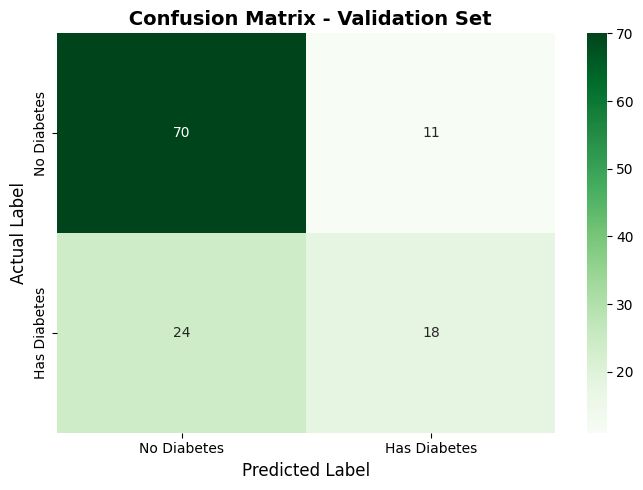

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_val_pred = final_model.predict(X_val)
y_val_prob = final_model.predict_proba(X_val)[:, 1]

val_accuracy  = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall    = recall_score(y_val, y_val_pred)
val_f1        = f1_score(y_val, y_val_pred)
val_auc       = roc_auc_score(y_val, y_val_prob)

print(" Final Model Performance on Validation Set:")
print("\n")
print(f"  Accuracy  : {val_accuracy*100:.2f}%")
print(f"  Precision : {val_precision*100:.2f}%")
print(f"  Recall    : {val_recall*100:.2f}%")
print(f"  F1 Score  : {val_f1*100:.2f}%")
print(f"  AUC Score : {val_auc*100:.2f}%")

cm_val = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_val,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'])

plt.title(' Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# ***Evaluate model on validation set.***

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall    = recall_score(y_test, y_test_pred)
f1        = f1_score(y_test, y_test_pred)
auc       = roc_auc_score(y_test, y_test_prob)

print("Final Model Performance on Test Set:")
print("\n")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print(f"  AUC Score : {auc*100:.2f}%")

Final Model Performance on Test Set:


  Accuracy  : 73.38%
  Precision : 65.91%
  Recall    : 52.73%
  F1 Score  : 58.59%
  AUC Score : 78.81%


# ***Evaluate final model on test set.***

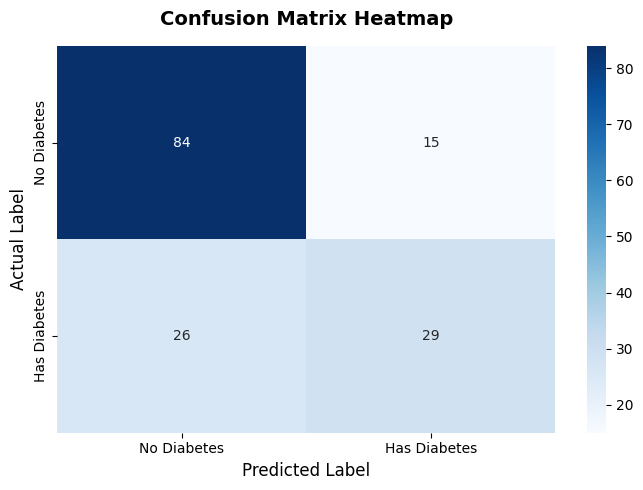

  True Negatives  (TN): 84 — Correctly predicted NO diabetes
  False Positives (FP): 15 — Said diabetes but actually NO diabetes
  False Negatives (FN): 26 — Said NO diabetes but actually HAS diabetes
  True Positives  (TP): 29 — Correctly predicted HAS diabetes


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'])

plt.title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives  (TN): {tn} — Correctly predicted NO diabetes")
print(f"  False Positives (FP): {fp} — Said diabetes but actually NO diabetes")
print(f"  False Negatives (FN): {fn} — Said NO diabetes but actually HAS diabetes")
print(f"  True Positives  (TP): {tp} — Correctly predicted HAS diabetes")

# ***Confusion matrix Heatmap.***

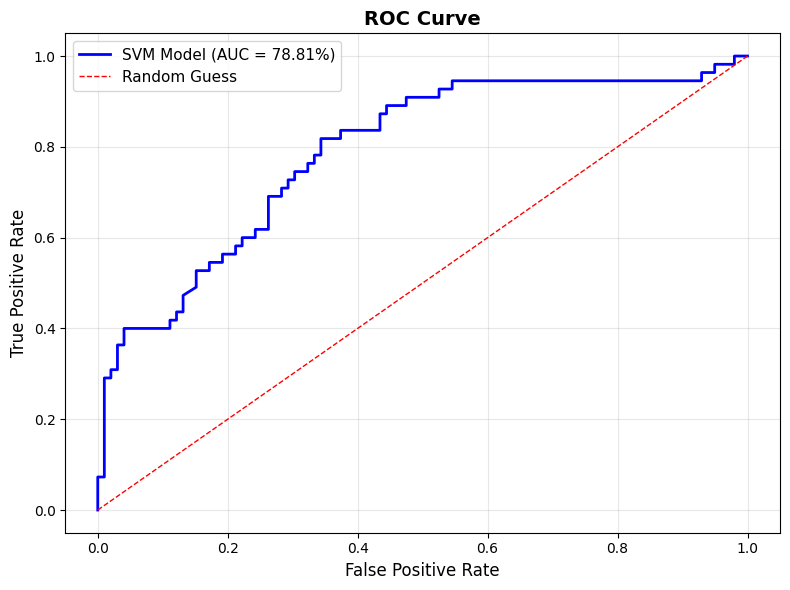

In [28]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f'SVM Model (AUC = {auc*100:.2f}%)')
plt.plot([0, 1], [0, 1], color='red', linewidth=1,
         linestyle='--', label='Random Guess')

plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ***ROC Curve.***

In [32]:
sample_indices = range(10)

actual    = list(y_test.values[:10])
predicted = list(y_test_pred[:10])
proba_no  = list((y_test_prob[:10] * -1 + 1).round(2))
proba_yes = list(y_test_prob[:10].round(2))

results = pd.DataFrame({
    'Actual'              : ['Diabetes' if a==1 else 'No Diabetes' for a in actual],
    'Predicted'           : ['Diabetes' if p==1 else 'No Diabetes' for p in predicted],
    'Prob - No Diabetes'  : proba_no,
    'Prob - Has Diabetes' : proba_yes,
    'Correct?'            : ['Right' if a==p else 'Wrong' for a,p in zip(actual, predicted)]
})

print("Sample Predictions vs Actual (First 10 patients):")
print("\n")
print(results.to_string(index=False))

Sample Predictions vs Actual (First 10 patients):


     Actual   Predicted  Prob - No Diabetes  Prob - Has Diabetes Correct?
No Diabetes No Diabetes                0.65                 0.35    Right
No Diabetes No Diabetes                0.93                 0.07    Right
No Diabetes No Diabetes                0.90                 0.10    Right
No Diabetes No Diabetes                0.79                 0.21    Right
No Diabetes No Diabetes                0.70                 0.30    Right
No Diabetes    Diabetes                0.40                 0.60    Wrong
No Diabetes No Diabetes                0.85                 0.15    Right
No Diabetes    Diabetes                0.29                 0.71    Wrong
No Diabetes    Diabetes                0.25                 0.75    Wrong
No Diabetes    Diabetes                0.30                 0.70    Wrong


# ***Sample predictions with probability scores.***

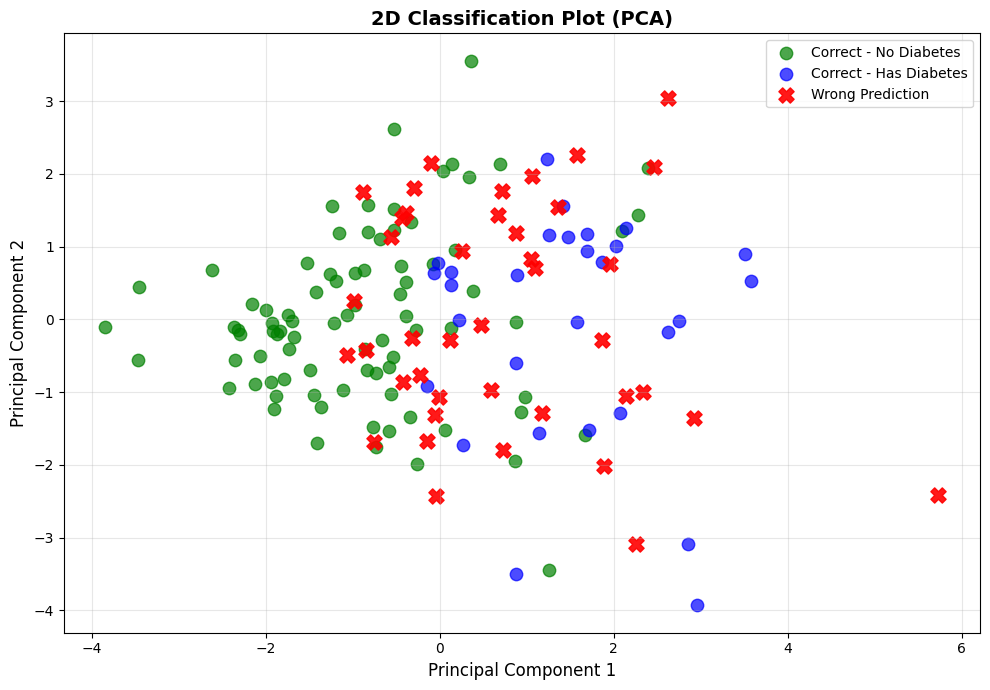

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)

y_pred_plot = final_model.predict(X_test)

plt.figure(figsize=(10, 7))

correct = y_test_pred == y_test.values
wrong   = y_test_pred != y_test.values

plt.scatter(X_test_2d[correct & (y_test.values==0), 0],
            X_test_2d[correct & (y_test.values==0), 1],
            color='green', marker='o', s=80, alpha=0.7, label='Correct - No Diabetes')

plt.scatter(X_test_2d[correct & (y_test.values==1), 0],
            X_test_2d[correct & (y_test.values==1), 1],
            color='blue', marker='o', s=80, alpha=0.7, label='Correct - Has Diabetes')

plt.scatter(X_test_2d[wrong, 0],
            X_test_2d[wrong, 1],
            color='red', marker='X', s=120, alpha=0.9, label='Wrong Prediction')

plt.title('2D Classification Plot (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ***2D classification plot.***

In [35]:
print("*"*55)
print("         FINAL SVM MODEL SUMMARY REPORT")
print("*"*55)

print("\n DATASET")
print(f"   Name         : Pima Indians Diabetes Dataset")
print(f"   Total Samples: 768 patients")
print(f"   Features     : 8 medical measurements")
print(f"   Target       : Diabetes Yes or No")

print("\n  BEST MODEL PARAMETERS")
for param, value in best_params.items():
    print(f"   {param:10s}: {value}")

print("\n EVALUATION METRICS")
print(f"   Accuracy     : {accuracy*100:.2f}%")
print(f"   Precision    : {precision*100:.2f}%")
print(f"   Recall       : {recall*100:.2f}%")
print(f"   F1 Score     : {f1*100:.2f}%")
print(f"   AUC Score    : {auc*100:.2f}%")

print("\n CONFUSION MATRIX")
print(f"   True Negatives  : {tn} (Correctly said No Diabetes)")
print(f"   True Positives  : {tp} (Correctly said Has Diabetes)")
print(f"   False Positives : {fp} (Said Diabetes but was wrong)")
print(f"   False Negatives : {fn} (Missed actual Diabetes cases)")

print("\n PREPROCESSING STEPS DONE")
print("   1. Replaced impossible zeros with median values")
print("   2. Standardized all features with StandardScaler")
print("   3. Split data into Train / Validation / Test sets")

print("\n HYPERPARAMETER TUNING")
print("   Method : GridSearchCV")
print("   Folds  : 5 Cross Validation")
print("   Tried  : kernel, C, gamma, degree combinations")

print("*"*55)
print("         ASSIGNMENT COMPLETE!")
print("*"*55)

*******************************************************
         FINAL SVM MODEL SUMMARY REPORT
*******************************************************

 DATASET
   Name         : Pima Indians Diabetes Dataset
   Total Samples: 768 patients
   Features     : 8 medical measurements
   Target       : Diabetes Yes or No

  BEST MODEL PARAMETERS
   C         : 1
   degree    : 2
   gamma     : auto
   kernel    : rbf

 EVALUATION METRICS
   Accuracy     : 73.38%
   Precision    : 65.91%
   Recall       : 52.73%
   F1 Score     : 58.59%
   AUC Score    : 78.81%

 CONFUSION MATRIX
   True Negatives  : 84 (Correctly said No Diabetes)
   True Positives  : 29 (Correctly said Has Diabetes)
   False Positives : 15 (Said Diabetes but was wrong)
   False Negatives : 26 (Missed actual Diabetes cases)

 PREPROCESSING STEPS DONE
   1. Replaced impossible zeros with median values
   2. Standardized all features with StandardScaler
   3. Split data into Train / Validation / Test sets

 HYPERPARAMETER TU

# ***Final summary report.***